In [19]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [20]:
# Load the dataset
file_path = "../data/raw/Uber-Jan-Feb-FOIL.csv"
df = pd.read_csv(file_path)

df.head()


,dispatching_base_number,date,active_vehicles,trips
0,B02512,1/1/2015,190,1132
1,B02765,1/1/2015,225,1765
2,B02764,1/1/2015,3427,29421
3,B02682,1/1/2015,945,7679
4,B02617,1/1/2015,1228,9537


In [21]:
df.info()
print(df.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dispatching_base_number  354 non-null    object
 1   date                     354 non-null    object
 2   active_vehicles          354 non-null    int64 
 3   trips                    354 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.2+ KB
Index(['dispatching_base_number', 'date', 'active_vehicles', 'trips'], dtype='object')


In [22]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by date
df = df.sort_values('date')

# Set date as index (for time series)
df.set_index('date', inplace=True)

df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 354 entries, 2015-01-01 to 2015-02-28
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dispatching_base_number  354 non-null    object
 1   active_vehicles          354 non-null    int64 
 2   trips                    354 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 11.1+ KB


In [23]:
# Aggregate daily trips
daily_trips = df.groupby('date')['trips'].sum().to_frame()

daily_trips.head()


,trips
date,
2015-01-01,56437
2015-01-02,39189
2015-01-03,58449
2015-01-04,40798
2015-01-05,42752


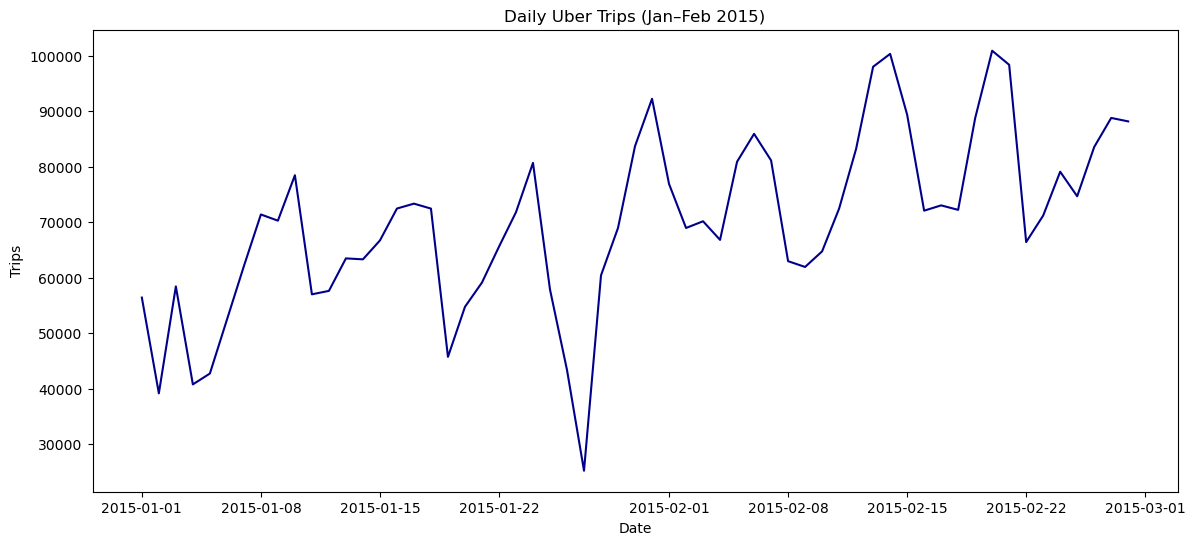

In [24]:
plt.figure(figsize=(14,6))
plt.plot(daily_trips['trips'], color='darkblue')
plt.title("Daily Uber Trips (Jan–Feb 2015)")
plt.xlabel("Date")
plt.ylabel("Trips")
plt.show()


In [25]:
def create_lagged_features(series, window=7):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

window_size = 7
X, y = create_lagged_features(daily_trips['trips'].values, window_size)


In [26]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [27]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_mape = mean_absolute_percentage_error(y_test, rf_preds)
print("Random Forest MAPE:", rf_mape)


Random Forest MAPE: 0.07863581175258814


In [28]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

gbr.fit(X_train, y_train)
gbr_preds = gbr.predict(X_test)

gbr_mape = mean_absolute_percentage_error(y_test, gbr_preds)
print("GBR MAPE:", gbr_mape)


GBR MAPE: 0.09219320019641732


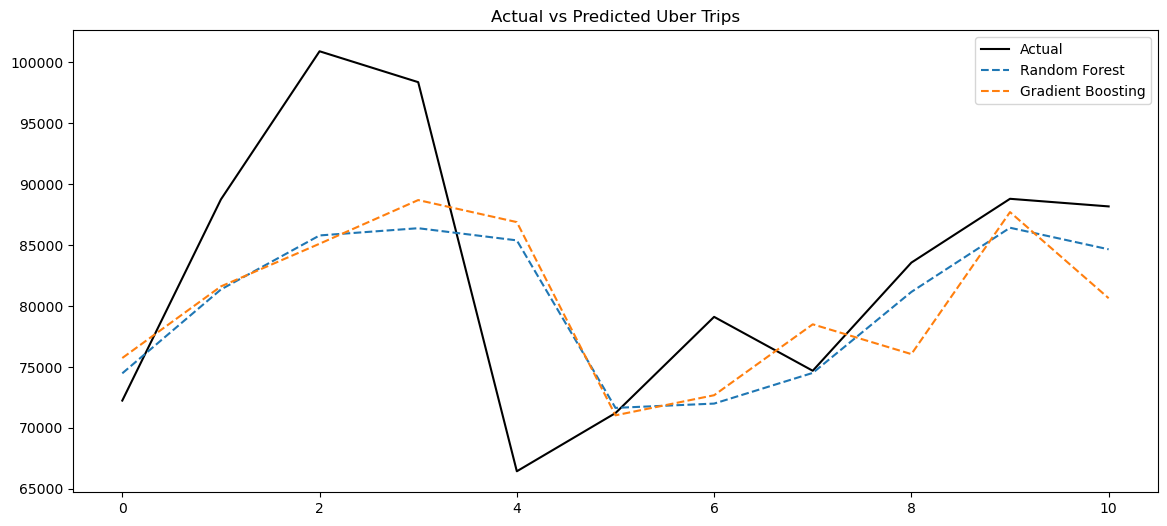

In [29]:
plt.figure(figsize=(14,6))
plt.plot(y_test, label="Actual", color="black")
plt.plot(rf_preds, label="Random Forest", linestyle="--")
plt.plot(gbr_preds, label="Gradient Boosting", linestyle="--")
plt.legend()
plt.title("Actual vs Predicted Uber Trips")
plt.show()


In [30]:
print(f"Random Forest MAPE: {rf_mape:.2%}")
print(f"Gradient Boosting MAPE: {gbr_mape:.2%}")


Random Forest MAPE: 7.86%
Gradient Boosting MAPE: 9.22%


In [31]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error

# Define weights (inverse of error → better model = higher weight)
rf_weight = 1 / rf_mape
gbr_weight = 1 / gbr_mape

total = rf_weight + gbr_weight
rf_weight /= total
gbr_weight /= total

# Ensemble prediction
ensemble_preds = (
    rf_weight * rf_preds +
    gbr_weight * gbr_preds
)

# Ensemble MAPE
ensemble_mape = mean_absolute_percentage_error(y_test, ensemble_preds)

print(f"Ensemble MAPE: {ensemble_mape:.2%}")


Ensemble MAPE: 8.44%


In [52]:
# Recreate date index for test set
test_dates = df.index[-len(y_test):]


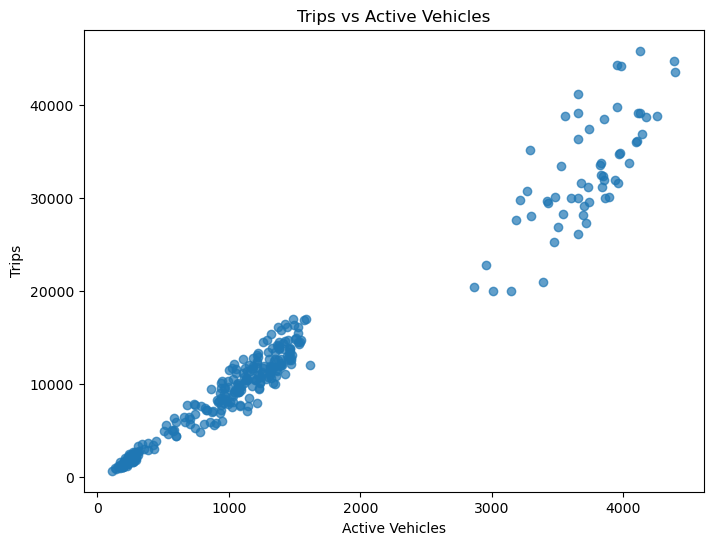

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(df['active_vehicles'], df['trips'], alpha=0.7)
plt.xlabel("Active Vehicles")
plt.ylabel("Trips")
plt.title("Trips vs Active Vehicles")
plt.show()


In [37]:
df[['active_vehicles', 'trips']].corr()


,active_vehicles,trips
active_vehicles,1.000000,0.980493
trips,0.980493,1.000000


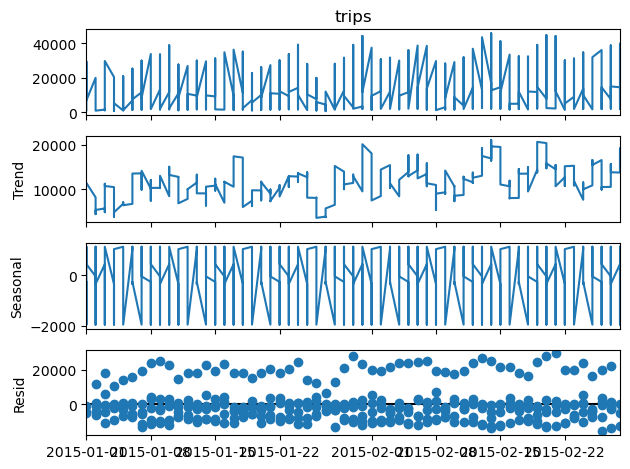

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df['trips'], model='additive', period=7)
decomp.plot()
plt.show()


In [40]:
import pandas as pd

# Convert y_test to pandas Series with date index
y_test_series = pd.Series(y_test, index=test_dates)


In [41]:
# Naive forecast = previous day's value
naive_preds = y_test_series.shift(1).bfill()

from sklearn.metrics import mean_absolute_percentage_error
naive_mape = mean_absolute_percentage_error(y_test_series, naive_preds)

print(f"Naive Baseline MAPE: {naive_mape:.2%}")


Naive Baseline MAPE: 11.01%


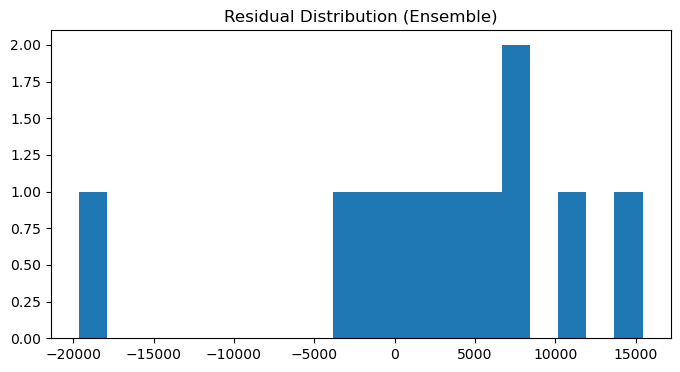

In [42]:
residuals = y_test - ensemble_preds

plt.figure(figsize=(8,4))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution (Ensemble)")
plt.show()


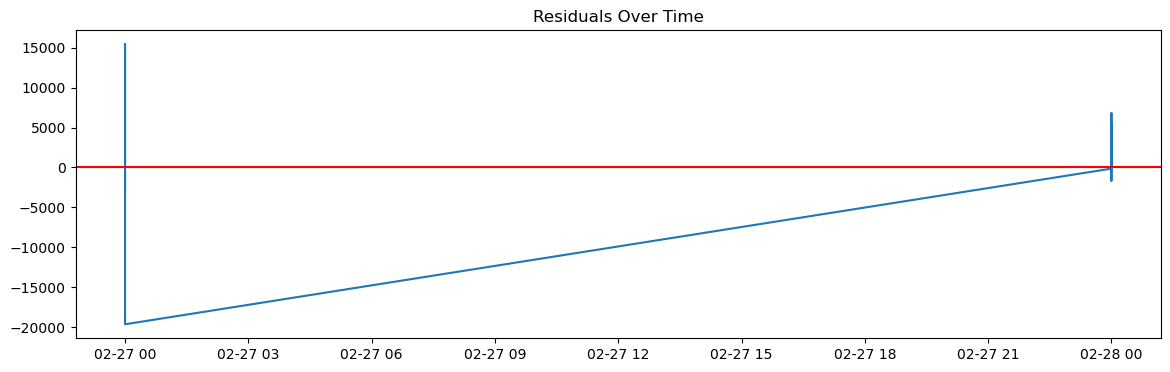

In [43]:
plt.figure(figsize=(14,4))
plt.plot(test_dates, residuals)
plt.axhline(0, color='red')
plt.title("Residuals Over Time")
plt.show()


In [45]:
# Convert y_test to pandas Series (if not already done)
import pandas as pd

y_test_series = pd.Series(y_test, index=test_dates)

# Naive forecast = previous day's trips
naive_preds = y_test_series.shift(1).bfill()

from sklearn.metrics import mean_absolute_percentage_error
naive_mape = mean_absolute_percentage_error(y_test_series, naive_preds)

print(f"Naive Baseline MAPE: {naive_mape:.2%}")


Naive Baseline MAPE: 11.01%


In [46]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Random Forest",
        "Gradient Boosting",
        "Ensemble"
    ],
    "MAPE (%)": [
        naive_mape * 100,
        rf_mape * 100,
        gbr_mape * 100,
        ensemble_mape * 100
    ]
})

results.sort_values("MAPE (%)", inplace=True)
results.reset_index(drop=True, inplace=True)

results


,Model,MAPE (%)
0,Random Forest,7.863581
1,Ensemble,8.442852
2,Gradient Boosting,9.219320
3,Naive Baseline,11.013363


In [47]:
results["Improvement vs Baseline (%)"] = (
    (naive_mape - results["MAPE (%)"] / 100) / naive_mape * 100
)

results


,Model,MAPE (%),Improvement vs Baseline (%)
0,Random Forest,7.863581,28.599637
1,Ensemble,8.442852,23.339924
2,Gradient Boosting,9.219320,16.289693
3,Naive Baseline,11.013363,0.000000


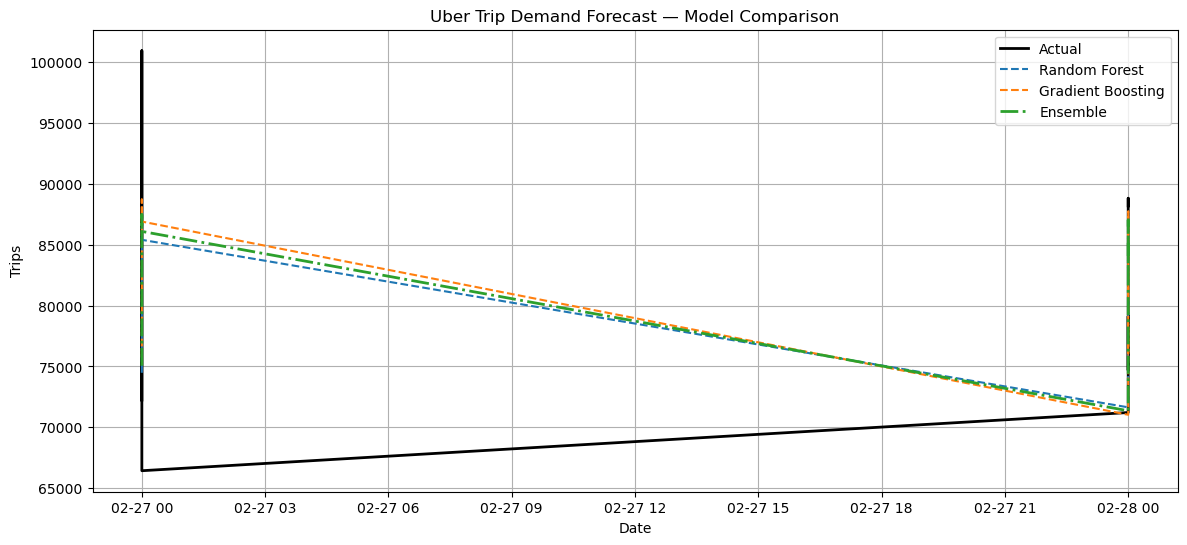

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(test_dates, y_test_series, label="Actual", color="black", linewidth=2)
plt.plot(test_dates, rf_preds, label="Random Forest", linestyle="--")
plt.plot(test_dates, gbr_preds, label="Gradient Boosting", linestyle="--")
plt.plot(test_dates, ensemble_preds, label="Ensemble", linestyle="-.", linewidth=2)

plt.title("Uber Trip Demand Forecast — Model Comparison")
plt.xlabel("Date")
plt.ylabel("Trips")
plt.legend()
plt.grid(True)
plt.show()


In [57]:
plt.savefig("../results/model_comparison_plots.png",
            dpi=300,
            bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

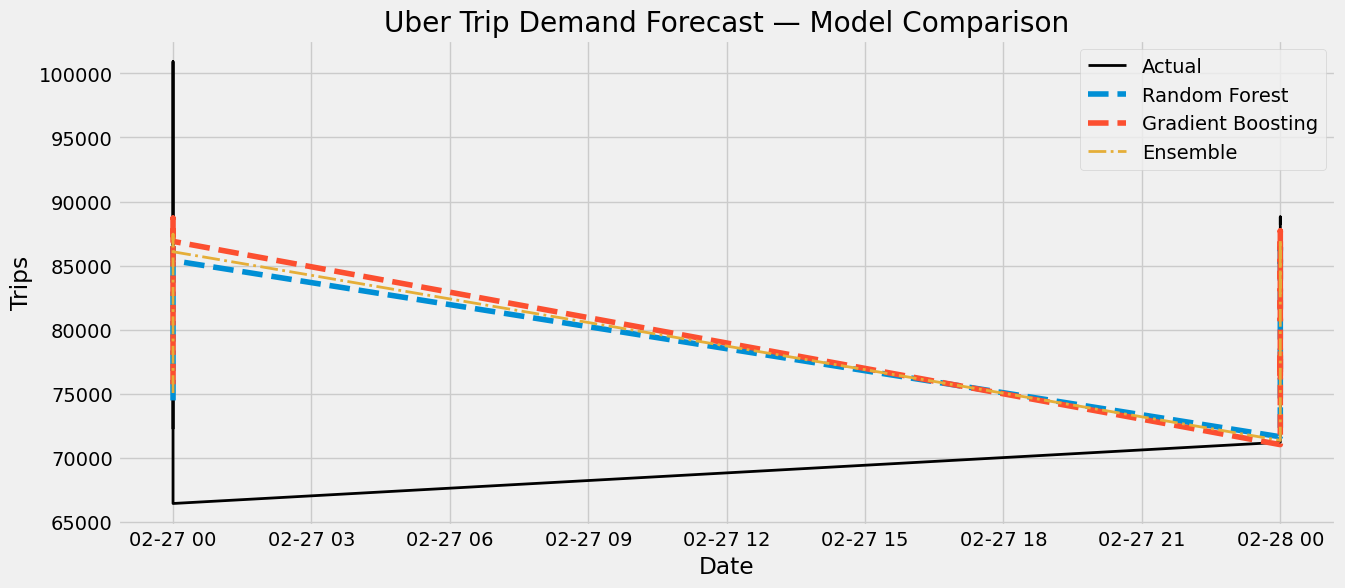

In [58]:
plt.figure(figsize=(14, 6))

plt.plot(test_dates, y_test_series, label="Actual", color="black", linewidth=2)
plt.plot(test_dates, rf_preds, label="Random Forest", linestyle="--")
plt.plot(test_dates, gbr_preds, label="Gradient Boosting", linestyle="--")
plt.plot(test_dates, ensemble_preds, label="Ensemble", linestyle="-.", linewidth=2)

plt.title("Uber Trip Demand Forecast — Model Comparison")
plt.xlabel("Date")
plt.ylabel("Trips")
plt.legend()
plt.grid(True)

plt.savefig("../results/model_comparison_plots.png", dpi=300, bbox_inches="tight")
plt.show()
